In [1]:
from notebook_setup import add_project_path_to_notebook
add_project_path_to_notebook()

In [2]:
from src.utils.paths import PROJECT_ROOT, SIMULATION_PATH

print("Found project root and path to simulated data at the following locations")
print(f"Project root: {PROJECT_ROOT}")
print(f"Simulation path: {SIMULATION_PATH}")

Found project root and path to simulated data at the following locations
Project root: /Users/scmps8/repos/github.com/microtorch/src
Simulation path: /Users/scmps8/repos/github.com/microtorch/simulation_data


In [3]:
#get the list of all the compartment names

import src.signal_models as sm

exclude = {'Standard_WM','t1_smdt'}

compartments = [c for c in sm.__all__ if c not in exclude]
compartments


['Ball', 'Msdki', 'Zeppelin', 'Ballt2', 'Sphere', 'Stick', 'Astrosticks']

In [4]:
import matplotlib.pyplot as plt

from src.model_maker import ModelMaker

modelfunc = {}

for compartment in compartments:            
    
    modelfunc[compartment] = ModelMaker(compartment)

    

No YAML configuration found for Ball model.
Falling back to parsing model name for compartments: ['Ball'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ball
########### Compartments: ['Ball']
########### Parameter names: [['D']]
########### Parameter ranges: [[[0.001, 3]]]
-----------
No YAML configuration found for Msdki model.
Falling back to parsing model name for compartments: ['Msdki'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Msdki
########### Compartments: ['Msdki']
########### Parameter names: [['D', 'K']]
########### Parameter ranges: [[[0.001, 3], [0.001, 2]]]
-----------
No YAML configuration found for Zeppelin model.
Falling back to parsing model name for compartments: ['Zeppelin'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Zeppelin
########### Compartments: ['Zeppelin']
########### Parameter names: [['Dpar', 'k', 't

In [5]:
from src.utils.acquisition_scheme import acquisition_scheme_loader
import os

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_HCP_with_deltas.txt"))

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_ivim_T2.txt"))

Assumed b-values are given in s/mm^2 and converted to ms/μm^2 for internal use. If this is not correct, please check your b-values and ensure they are in the correct units.
Calculated gradient strengths from b-values and timing parameters.
Assuming b-values are in ms/μm^2, delta and Delta are in ms. Gradient strengths will be in mT/μm.
Assumed TE values are given in ms and converted to seconds for internal use. If this is not correct, please check your TE values and ensure they are in the correct units.
Calculated gradient strengths from b-values and timing parameters.
Assuming b-values are in ms/μm^2, delta and Delta are in ms. Gradient strengths will be in mT/μm.


In [6]:
import torch
import matplotlib.pyplot as plt 
from src.utils.make_test_image import generate_random_params

S = {}
n_samples = 5

for compartment in compartments:
    #randomly sample a parameter set from the parameter space of the model.
    params = generate_random_params(modelfunc[compartment], n_samples)

    S[compartment] = modelfunc[compartment](grad, params).unsqueeze(0)




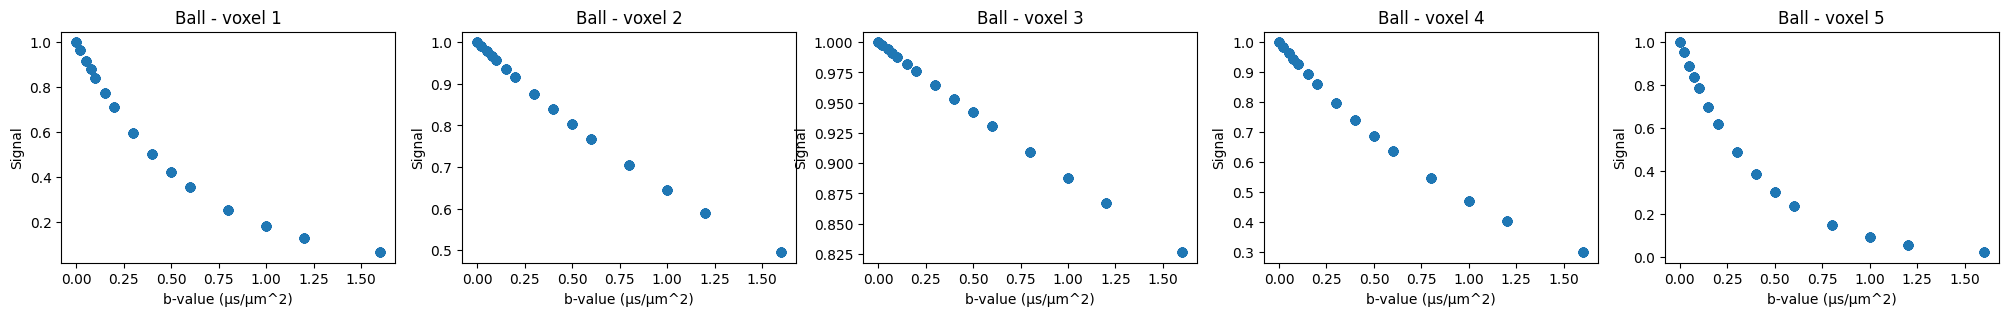

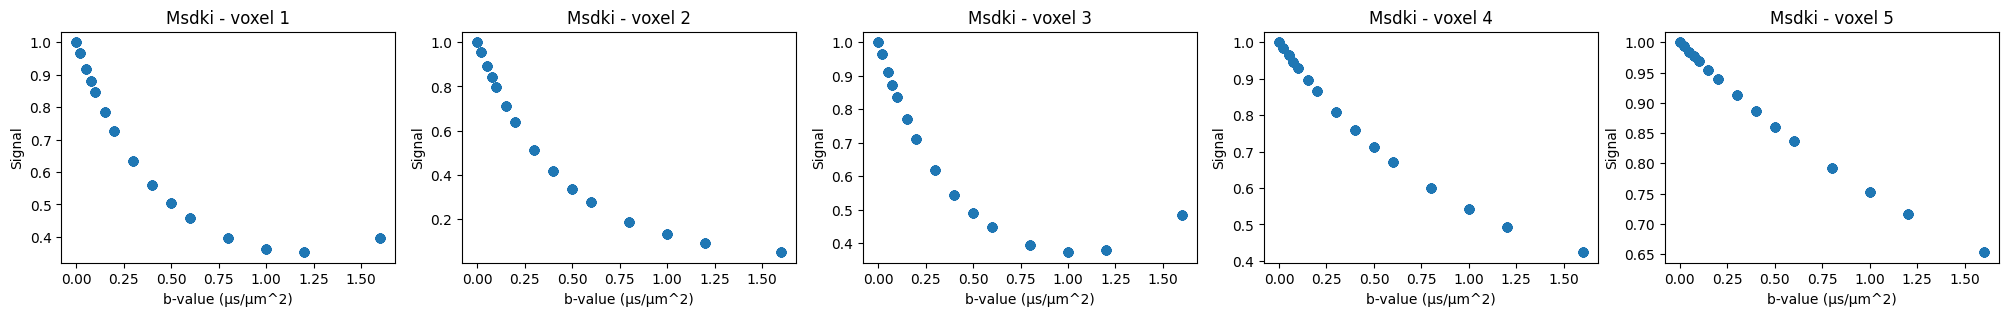

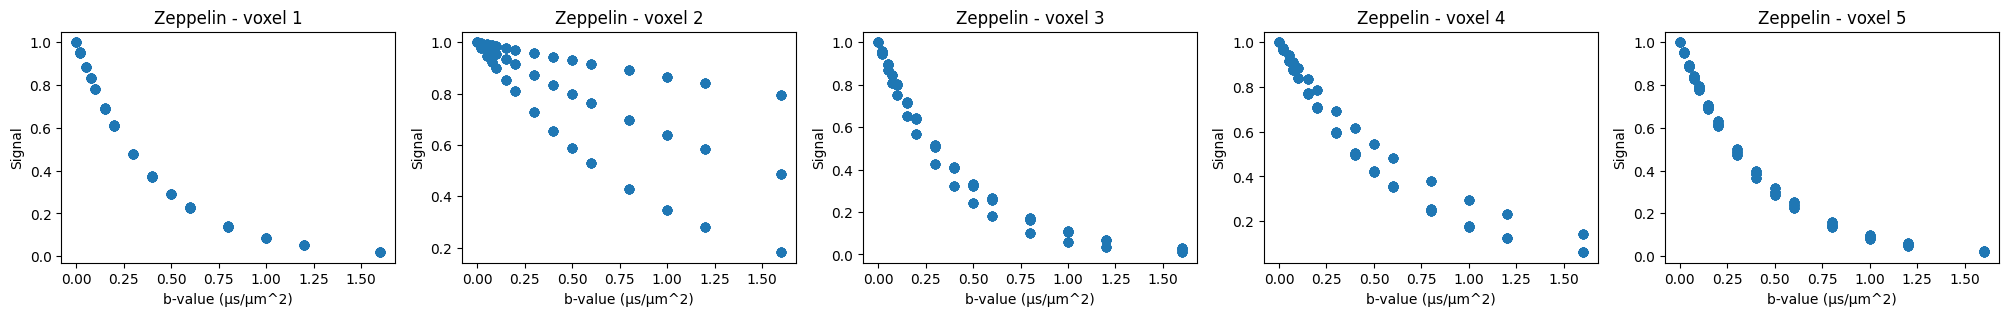

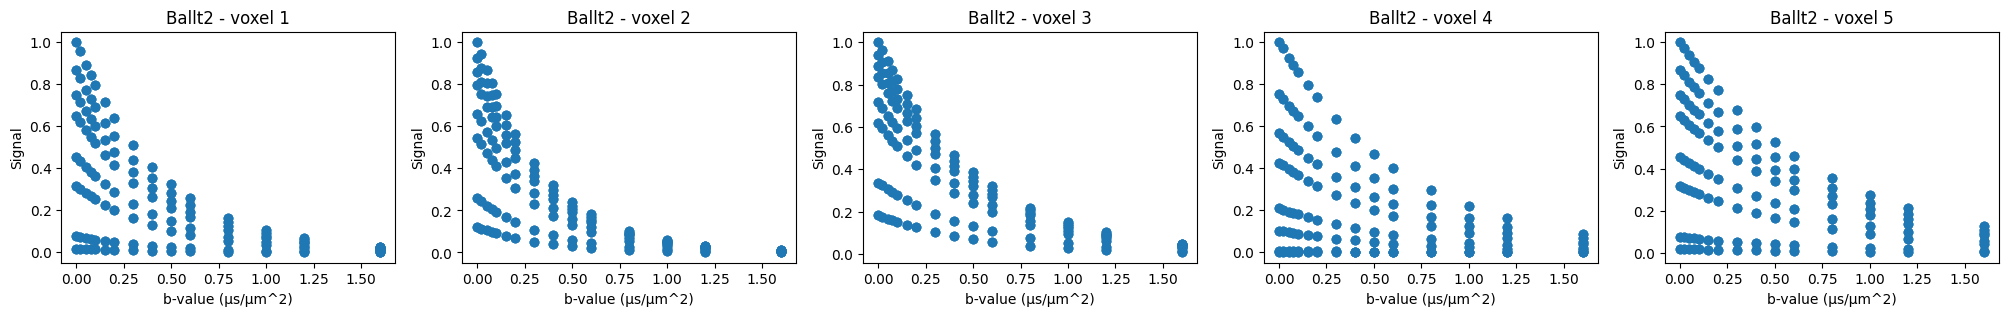

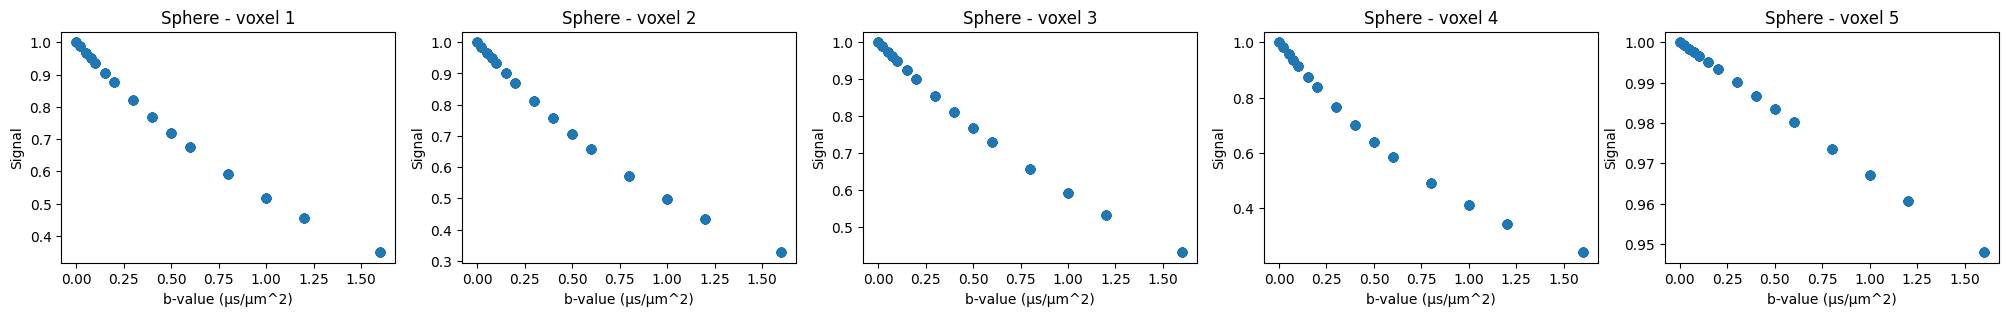

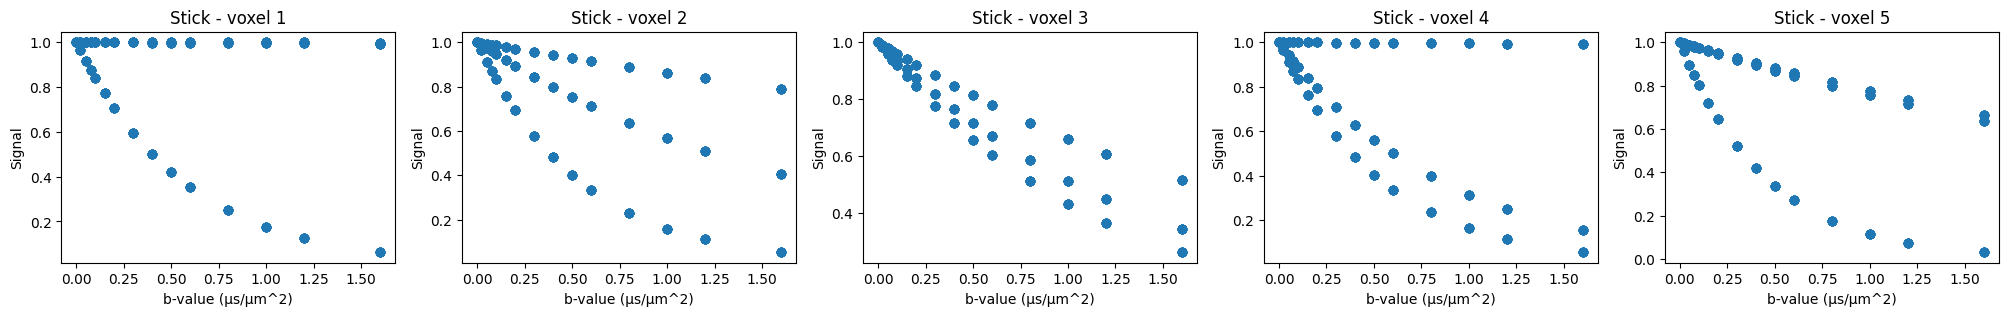

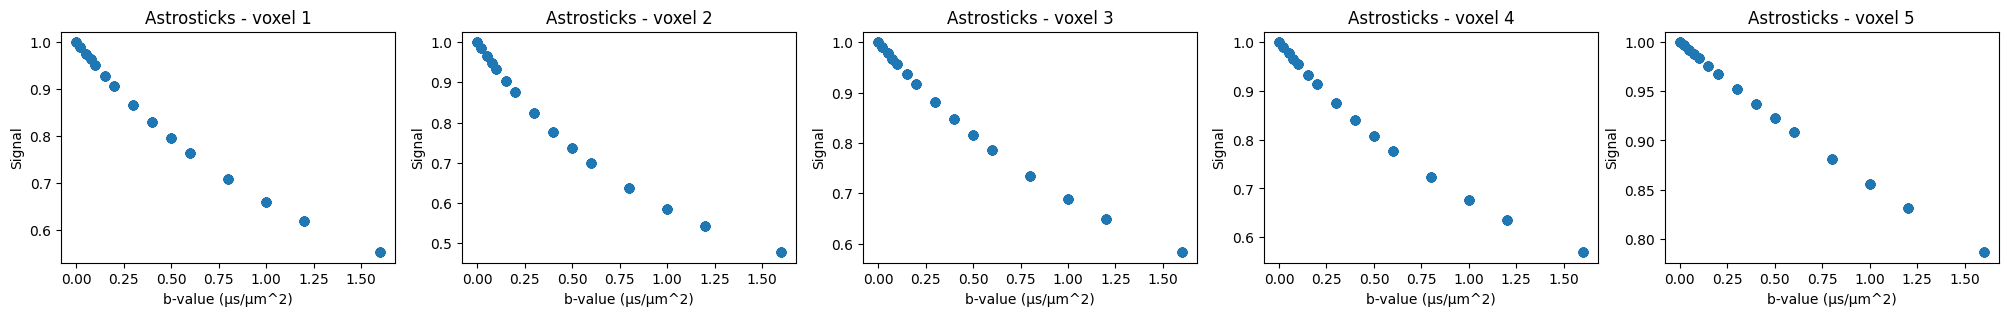

In [7]:
for compartment in compartments:
    n_voxels = S[compartment].shape[1]
    _, ax = plt.subplots(1, n_voxels, figsize=(5 * n_voxels, 3))
    for i in range(n_voxels):
        ax[i].plot(grad.bvalues, S[compartment][0,i,:],'o')
        ax[i].set_title(f"{compartment} - voxel {i+1}")

        ax[i].set_xlabel("b-value (μs/μm^2)")
        ax[i].set_ylabel("Signal")